In [57]:
import os
import glob
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import esmpy
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as ticker
from scipy.spatial import KDTree
import datetime

### Coupled Simulation Results

**Table 1:** Detailed information about conducted simulations
| #  | Data Component | Input     | Temporal Interpolation Type | Coupling Type      | Feedback                 |
|----|----------------|-----------|-----------------------------|--------------------|--------------------------|
| r1 | CDEPS          | ERA5 (6h) | coszen                      | one-way: ATM->OCN  | No                       |
| r2 | CDEPS          | ERA5 (1h) | coszen                      | one-way: ATM->OCN  | No                       |
| r3 | CDEPS          | ERA5 (6h) | linear                      | one-way: ATM->OCN  | No                       |
| r4 | CDEPS          | ERA5 (1h) | linear                      | one-way: ATM->OCN  | No                       |
| r5 | Aurora         | ERA5 (6h) | linear                      | one-way: ATM->OCN  | No                       |
| r6 | Aurora         | ERA5 (6h) | linear                      | two-way: ATM<->OCN | Yes, SST from OCN to ATM |

In [192]:
# List of variables to keep
vars = {
    'Pair': [995, 1015],
    'Tair': [20, 28],
    'Uwind': [-5, 10],
    'Vwind': [0, 12],
    'swrad': [50, 200],
    'lwrad': [-25, 25],
    'latent': [-100, 100],
    'sensible': [-20, 100],
    'temp': [16, 26],
    'zeta' : [-0.2, 0.6]
}
var_names = list(vars.keys())

# Open datasets and merge them
# No shift means that the origianal ERA5 dataset not shifted in time
ds1 = xr.open_dataset("../run_cdeps/r1/irene_his.nc").isel(s_rho=-1)[var_names]
ds2 = xr.open_dataset("../run_cdeps/r2/irene_his.nc").isel(s_rho=-1)[var_names]
ds3 = xr.open_dataset("../run_cdeps/r3/irene_his.nc").isel(s_rho=-1)[var_names]
ds4 = xr.open_dataset("../run_cdeps/r4/irene_his.nc").isel(s_rho=-1)[var_names]
ds5 = xr.open_dataset("../run/r5/irene_his.nc").isel(s_rho=-1)[var_names]
ds6 = xr.open_dataset("../run/r6/irene_his.nc").isel(s_rho=-1)[var_names]
ds = xr.concat([ds1, ds2, ds3, ds4, ds5, ds6], dim='run_id')

# Load roms grid
grid = xr.open_dataset('../run/Data/ROMS/irene_roms_grid.nc')

In [193]:
ds

<xarray.Dataset> Size: 530MB
Dimensions:     (run_id: 6, ocean_time: 43, eta_rho: 106, xi_rho: 242)
Coordinates:
  * ocean_time  (ocean_time) datetime64[ns] 344B 2011-08-27T06:00:00 ... 2011...
    s_rho       float64 8B -0.0125
    lon_rho     (eta_rho, xi_rho) float64 205kB -75.19 -75.13 ... -64.62 -64.54
    lat_rho     (eta_rho, xi_rho) float64 205kB 32.24 32.28 ... 46.58 46.61
Dimensions without coordinates: run_id, eta_rho, xi_rho
Data variables:
    Pair        (run_id, ocean_time, eta_rho, xi_rho) float64 53MB 990.3 ... nan
    Tair        (run_id, ocean_time, eta_rho, xi_rho) float64 53MB 26.72 ... nan
    Uwind       (run_id, ocean_time, eta_rho, xi_rho) float64 53MB 20.51 ... nan
    Vwind       (run_id, ocean_time, eta_rho, xi_rho) float64 53MB 15.9 ... nan
    swrad       (run_id, ocean_time, eta_rho, xi_rho) float64 53MB 0.0 ... nan
    lwrad       (run_id, ocean_time, eta_rho, xi_rho) float64 53MB -9.085 ......
    latent      (run_id, ocean_time, eta_rho, xi_rho) float64 53MB -245.4 ......
    sensible    (run_id, ocean_time, eta_rho, xi_rho) float64 53MB -18.76 ......
    temp        (run_id, ocean_time, eta_rho, xi_rho) float64 53MB 27.04 ... nan
    zeta        (run_id, ocean_time, eta_rho, xi_rho) float64 53MB 0.4541 ......
Attributes: (12/33)
    file:              irene_his.nc
    format:            netCDF-3 64bit offset file
    Conventions:       CF-1.4, SGRID-0.3
    type:              ROMS history file
    title:             Hurricane Irene, 27-29 Aug 2011
    var_info:          varinfo.yaml
    ...                ...
    compiler_command:  /opt/cray/pe/mpich/8.1.27/ofi/gnu/9.1/bin/mpif90
    compiler_flags:    -I/glade/work/turuncu/ML/envs/spack-1.0.2/var/spack/en...
    tiling:            3x4
    history:           ROMS, Version 4.3, Thursday - January 15, 2026 - 12:56...
    ana_file:          ROMS/Functionals/ana_btflux.h
    CPP_options:       IRENE, ADD_FSOBC, ADD_M2OBC, ANA_BSFLUX, ANA_BTFLUX, A...

### Compare Simulations

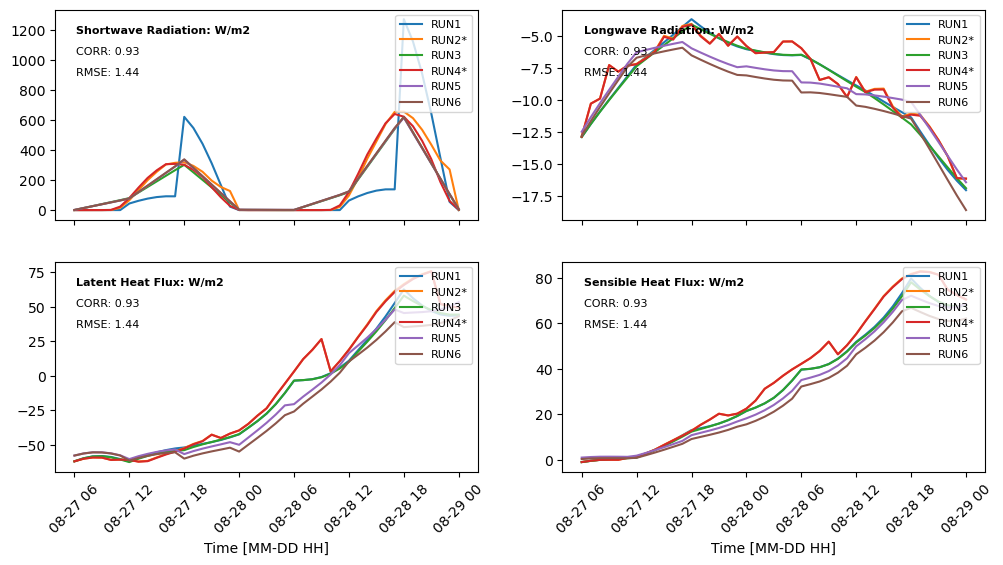

In [164]:
nrow = 2
ncol = 2
fig, ax = plt.subplots(nrow, ncol, figsize=(12,6))
x = pd.date_range("2011-08-27T06:00:00", "2011-08-29T00:00:00", freq="1h")

var_list = {
    'swrad': ['W/m2', 'SW', 'Shortwave Radiation'],
    'lwrad': ['W/m2', 'LW', 'Longwave Radiation'],
    'latent': ['W/m2', 'LH', 'Latent Heat Flux'],
    'sensible': ['W/m2', 'SH', 'Sensible Heat Flux'],
}

i = 0
for v in var_list.keys():
    irow = i // ncol
    icol = i % ncol

    for id in ds.run_id.values:
        data = ds[f"{v}"].where(grid.mask_rho > 0).isel(run_id=id).mean(dim=['eta_rho', 'xi_rho'])
        if id in [1, 3]: # forced with 1h dataset
            ax[irow,icol].plot(x, data, label=f"RUN{id+1}*")
        else:
            ax[irow,icol].plot(x, data, label=f"RUN{id+1}")
    
    if irow == nrow-1:
        ax[irow,icol].set_xlabel('Time [MM-DD HH]')
    else:
        ax[irow,icol].set_xticklabels([])
        ax[irow,icol].set_xlabel('')
    ax[irow,icol].tick_params(axis='x', labelrotation=45)
    ax[irow,icol].legend(ncol=1, fontsize=8, loc='upper right')
    ax[irow, icol].text(0.05, 0.9, f'{var_list[f'{v}'][2]}: {var_list[f'{v}'][0]}', fontsize=8, fontweight='bold', horizontalalignment='left', verticalalignment='center', multialignment='center', transform=ax[irow, icol].transAxes)
    ax[irow, icol].text(0.05, 0.8, f'CORR: {corr:.2f}', fontsize=8, horizontalalignment='left', verticalalignment='center', multialignment='center', transform=ax[irow, icol].transAxes)
    ax[irow, icol].text(0.05, 0.7, f'RMSE: {rmse:.2f}', fontsize=8, horizontalalignment='left', verticalalignment='center', multialignment='center', transform=ax[irow, icol].transAxes)
    
    i=i+1

# Save figure
#plt.tight_layout(rect=[0, 0, 1, 0.98])
#fig.savefig(f"Fig_run_3vs5.png")

In [155]:
def add_gridlines(ax):
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False

def add_features(ax):
    ax.add_feature(cfeature.COASTLINE, alpha=0.4)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2)
    ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.5)
    ax.add_feature(cfeature.LAKES, alpha=0.5)
    ax.stock_img()

def add_roms_box(ax, grid):
    ax.plot(grid.lon_rho[0, :], grid.lat_rho[0, :], color='black', linewidth=1, linestyle='--', transform=ccrs.PlateCarree()) # Bottom
    ax.plot(grid.lon_rho[:, 0], grid.lat_rho[:, 0], color='black', linewidth=1, linestyle='--', transform=ccrs.PlateCarree()) # Left
    ax.plot(grid.lon_rho[-1, :], grid.lat_rho[-1, :], color='black', linewidth=1, linestyle='--', transform=ccrs.PlateCarree()) # Top
    ax.plot(grid.lon_rho[:, -1], grid.lat_rho[:, -1], color='black', linewidth=1, linestyle='--', transform=ccrs.PlateCarree()) # Right

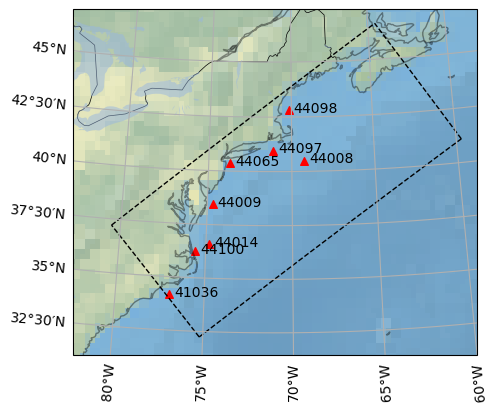

In [172]:
# Define bounding box limits
min_lat, max_lat = 31, 47
min_lon, max_lon = 278, 300

# Set projection
projection = ccrs.LambertConformal(
    central_longitude=(min_lon+max_lon)/2.0, 
    central_latitude=(min_lat+max_lat)/2.0, 
    standard_parallels=(20.0, 40.0)
)

# Create figure
fig, ax = plt.subplots(1, 1,
    figsize=(12, 4), 
    layout='constrained', 
    subplot_kw={'projection': projection})

# Plot map
add_features(ax)
add_roms_box(ax, grid)
add_gridlines(ax)
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

# Add observation locations
obs_loc = {
    "41036": [76.949, 34.207, "Onslow Bay Outer, NC", 0.3, -0.1, 'upper left'],
    "44009": [74.692, 38.460, "DELAWARE BAY 26 NM Southeast of Cape May, NJ", 0.3, -0.1, 'upper right'],
    "44065": [73.701, 40.368, "New York Harbor Entrance - 15 NM SE of Breezy Point , NY", 0.3, -0.1, 'lower left'],
    "44100": [75.593, 36.258, "Duck FRF 26m, NC (430)", 0.3, -0.1, 'upper left'],
    "44014": [74.837, 36.603, "VIRGINIA BEACH 64 NM East of Virginia Beach, VA", 0.3, -0.1, 'lower left'],
    "44097": [71.124, 40.967, "Block Island, RI (154)", 0.3, -0.1, 'lower left'],
    "44008": [69.254, 40.500, "NANTUCKET 54 NM Southeast of Nantucket", 0.3, -0.1, 'lower left'],
    "44098": [70.169, 42.800, "Jeffrey's Ledge, NH (160)", 0.3, -0.1, 'lower left'],
}

for key, val in obs_loc.items():
    lon = 360-val[0]
    lat = val[1]
    ax.scatter(lon, lat, marker='^', s=30, color='red', label=key, transform=ccrs.PlateCarree())
    ax.text(lon+val[3], lat+val[4], key, transform=ccrs.PlateCarree())

filename = "insitu_loc.png"
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)

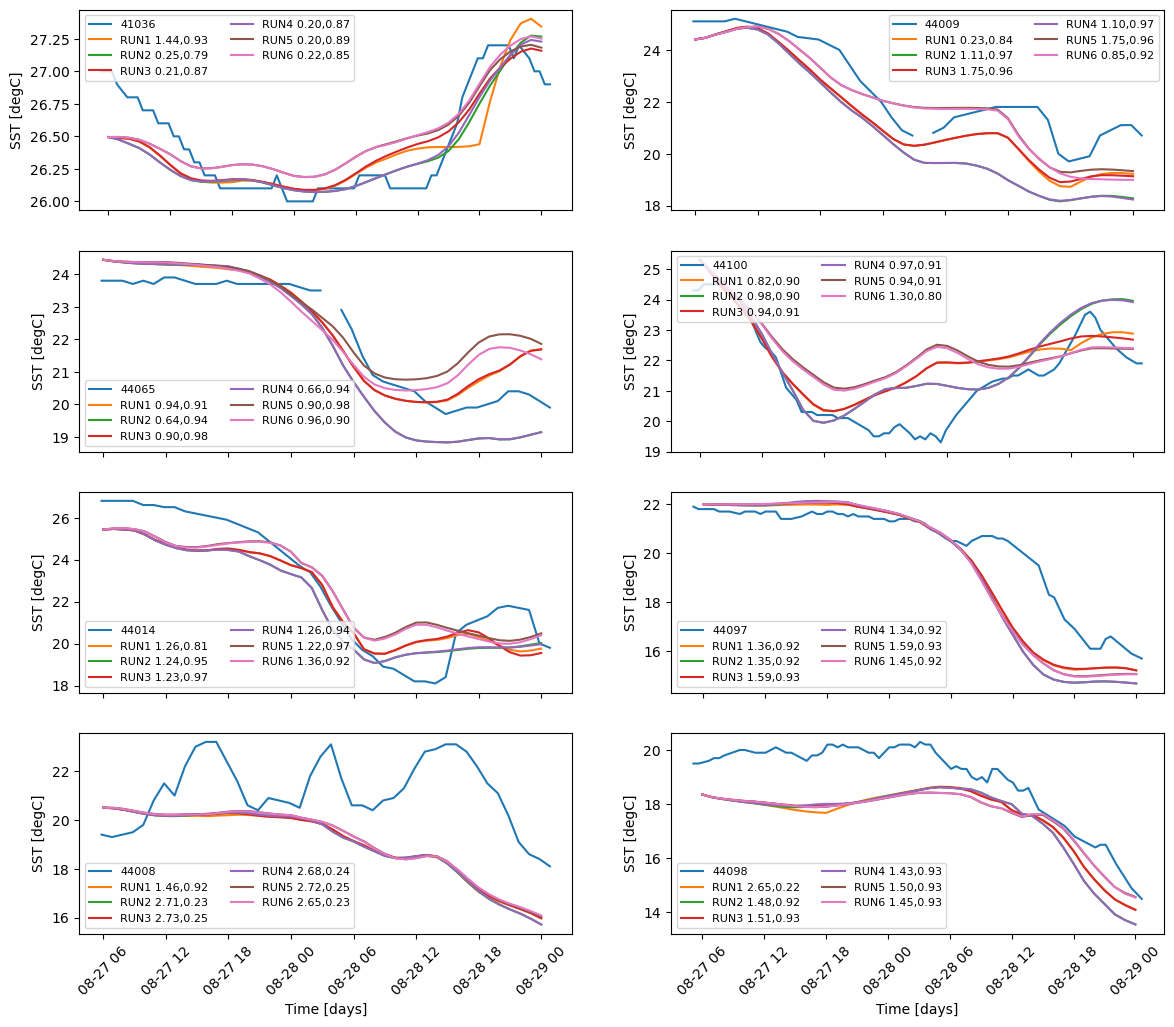

In [171]:
fig, ax = plt.subplots(4, 2, figsize=(14,12))
ax_flat = ax.flatten()
h1 = datetime.timedelta(hours=1)
x = pd.to_datetime(ds.ocean_time)

indx = 0
for key, val in obs_loc.items():    
    # Read in observation
    df = pd.read_csv(f'data/{key}h2011.txt', sep='\\s+', skiprows = [1])
    df.columns = df.columns.str.replace('#', '')
    df = df.rename(columns={'YY': 'year', 'MM': 'month', 'DD': 'day', 'hh': 'hour', 'mm': 'minute'})
    df['Date'] = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute']])
    time_mask = (df['Date']>= x[0]-h1) & (df['Date'] <= x[-1]+h1)
    df = df[time_mask]
    df = df.set_index(df['Date'])
    df['WTMP'] = df['WTMP'].where(df['WTMP'] < 40)

    # Plot observation, mask outliers or measurement errors
    ax_flat[indx].plot(df['Date'], df['WTMP'], label=f"{key}")

    # Perform temporal interpolation to simulation time to calculate statistics
    new_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq='10min')
    df_interp = df.reindex(new_index).interpolate(method='linear').resample('h').mean()[1:]

    # Find closest grid point for model data
    points = np.vstack((grid.lat_rho.values.flatten(), grid.lon_rho.values.flatten())).T
    tree = KDTree(points)
    distance, index = tree.query([val[1], -1.0*val[0]])
    lat_index, lon_index = np.unravel_index(index, grid.lon_rho.shape)

    # Get model data and plot
    for id in ds.run_id.values:
        # Plot
        data = ds['temp'].isel(run_id=id, eta_rho=lat_index, xi_rho=lon_index)
        ax_flat[indx].plot(x, data, label=f'RUN{id+1} {rmse:.2f},{corr:.2f}')
        # Calculate RMSE and correlation
        rmse = np.sqrt(np.mean((data - df_interp['WTMP']).data ** 2))
        corr = np.corrcoef(data, df_interp['WTMP'])[0, 1]

    # Set x-axis
    ax_flat[indx].tick_params(axis='x', labelrotation=45)
    ax_flat[indx].set_xlabel('Time [days]', fontsize=10)
    if indx < 6: 
        ax_flat[indx].set_xticklabels([])
        ax_flat[indx].set_xlabel('')

    # Set y-axis
    ax_flat[indx].set_ylabel('SST [degC]', fontsize=10)

    # Add label
    ax_flat[indx].legend(ncol=2, fontsize=8, loc=val[5])

    indx = indx+1

filename = "insitu_sst.png"
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)

In [198]:
var_list = {
    'PRES': 'Pair',
    'ATMP': 'Tair',
    'WTMP': 'temp',
}

data_list = []
for key, val in obs_loc.items():
    for var_obs, var_model in var_list.items():
        # Read in observation
        df = pd.read_csv(f'data/{key}h2011.txt', sep='\\s+', skiprows = [1])
        df.columns = df.columns.str.replace('#', '')
        df = df.rename(columns={'YY': 'year', 'MM': 'month', 'DD': 'day', 'hh': 'hour', 'mm': 'minute'})
        df['Date'] = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute']])
        time_mask = (df['Date']>= x[0]-h1) & (df['Date'] <= x[-1]+h1)
        df = df[time_mask]
        df = df.set_index(df['Date'])
        df['WTMP'] = df['WTMP'].where(df['WTMP'] < 40)
        df['ATMP'] = df['ATMP'].where(df['ATMP'] < 40)
        df['PRES'] = df['PRES'].where(df['PRES'] < 1200)

        # Perform temporal interpolation to simulation time to calculate statistics
        new_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq='10min')
        df_interp = df.reindex(new_index).interpolate(method='linear').resample('h').mean()[1:]
        #print(df_interp[var_obs].min(), df_interp[var_obs].max())

        # Find closest grid point for model data
        points = np.vstack((grid.lat_rho.values.flatten(), grid.lon_rho.values.flatten())).T
        tree = KDTree(points)
        distance, index = tree.query([val[1], -1.0*val[0]])
        lat_index, lon_index = np.unravel_index(index, grid.lon_rho.shape)

        # Loop over model simulations
        for id in ds.run_id.values:
            # Get model data
            data = ds[var_model].isel(run_id=id, eta_rho=lat_index, xi_rho=lon_index)
            #print(id, data.min().values, data.max().values)
            # Calculate RMSE and correlation
            rmse = np.sqrt(np.mean((data - df_interp[var_obs]).data ** 2))
            corr = np.corrcoef(data, df_interp[var_obs])[0, 1]
            # Add to datalist
            data_list.append(
                {
                    "station": key,
                    "variable": var_obs,
                    "simulation_id": id,
                    "rmse": rmse,
                    "corr": corr
                }
            )

# Convert to data frame
df = pd.DataFrame.from_records(data_list)
df = df.set_index(["station", "variable", "simulation_id"])

# Convert to dataset
ds_out = xr.Dataset.from_dataframe(df)
ds_out.to_netcdf("stats_insitu_sst.nc")

In [199]:
ds_out

<xarray.Dataset> Size: 2kB
Dimensions:        (station: 8, variable: 3, simulation_id: 6)
Coordinates:
  * station        (station) object 64B '41036' '44008' ... '44098' '44100'
  * variable       (variable) object 24B 'ATMP' 'PRES' 'WTMP'
  * simulation_id  (simulation_id) int64 48B 0 1 2 3 4 5
Data variables:
    rmse           (station, variable, simulation_id) float64 1kB 1.017 ... 1.26
    corr           (station, variable, simulation_id) float64 1kB 0.5285 ... ...

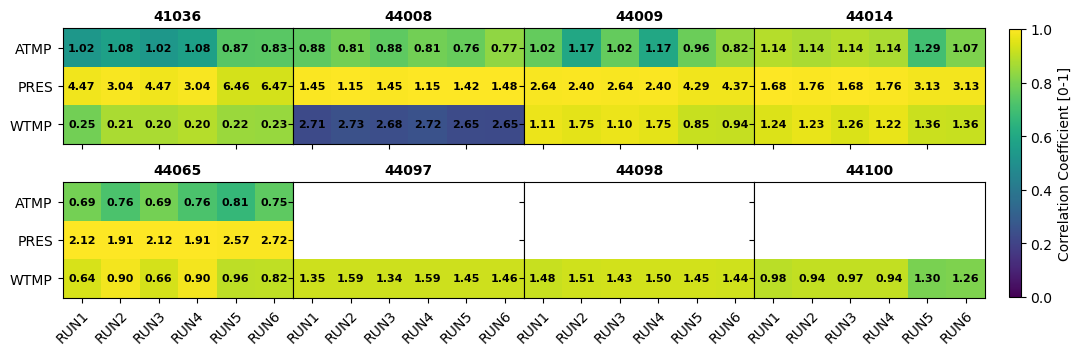

In [264]:
stations = ds_out.station.values
nstation = len(stations)

simulations = [ f'RUN{id+1}' for id in ds_out.simulation_id.values ]
vars = ds_out.variable.values

fig, ax = plt.subplots(2, nstation//2, figsize=(11.9,4), gridspec_kw={'wspace': 0.00, 'hspace': 0.00})
ax_flat = ax.flatten()

indx = 0
for s in ds_out.station:
    data_corr = ds_out.corr.sel(station=s)
    im = ax_flat[indx].imshow(data_corr, cmap="viridis", vmin=0, vmax=1)
    ax_flat[indx].set_xticklabels([])
    ax_flat[indx].set_xlabel('')
    ax_flat[indx].set_yticklabels([])
    ax_flat[indx].set_ylabel('')
    ax_flat[indx].set_title(s.values, fontsize=10, fontweight='bold')
    if indx > 3:
        ax_flat[indx].set_xticks(range(len(simulations)), labels=simulations, fontsize=10, rotation=45, ha="right", rotation_mode="anchor")
    if indx in [0, 4]:
        ax_flat[indx].set_yticks(range(len(vars)), labels=vars, fontsize=10)

    # Add RMSE
    j = 0
    for id in ds_out.simulation_id.values:
        i = 0
        for v in vars:
            data_rmse = ds_out.rmse.sel(station=s, simulation_id=id, variable=v)
            if not np.isnan(data_rmse):
                text = ax_flat[indx].text(j, i, f'{data_rmse:.2f}', ha="center", va="center", fontweight='bold', fontsize=8, color="black")
            i=i+1
        j=j+1
        
    indx = indx+1

cbar_ax = fig.add_axes([0.92, 0.16, 0.01, 0.67])
fig.colorbar(ax_flat[0].images[0], cax=cbar_ax, label='Correlation Coefficient [0-1]')

filename = "insitu_stats.png"
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)